# 🤖 NIELIT Delhi — Bootcamp on Artificial Intelligence
## Master Assignment: Supervised & Unsupervised Machine Learning
**Filename:** `Assignment_3.ipynb`  
**Student Name:** NIELIT AI Bootcamp Participant  
**Institute:** National Institute of Electronics & Information Technology (NIELIT), Delhi  

---

### 📌 Assignment Overview & Objectives
This single comprehensive notebook covers all three assigned machine learning challenges:

1. **Assignment 1 — Decision Tree Classifier & Depth Comparative Analysis:**
   - Design and train a Decision Tree model to predict student performance (`Pass` vs `Fail`) using `study_hours`, `attendance`, and `assignments`.
   - Experiment with varying tree depths (`max_depth = 3, 4, 5`).
   - Perform a comparative analysis of model performance, tree complexity, and the **Bias-Variance Tradeoff**.
   - Visualize learned decision trees and comparative evaluation metrics.

2. **Assignment 2 — Linear Regression in the Electronics Industry:**
   - Formulate a real-world electronics engineering problem: **Semiconductor Microchip Thermal Dissipation & Junction Temperature ($T_j$) Prediction**.
   - Model the physical relationship: $P_{total} \propto C \cdot V^2 \cdot f + V \cdot I_{leak}$ and $T_{junction} = T_{ambient} + \theta_{ja} \cdot P_{total}$.
   - Train a Multiple Linear Regression model, evaluate with $R^2$, $MAE$, $MSE$, $RMSE$, and validate physical coefficient interpretations.
   - Demonstrate hardware safety engineering decisions for overclocked embedded processors.

3. **Assignment 3 — Unsupervised Learning (K-Means Clustering & PCA):**
   - Apply unsupervised clustering to **Smart Electronics & Consumer Gadget Market Segmentation**.
   - Implement feature standardization (`StandardScaler`).
   - Determine optimal cluster count using the **Elbow Method (Inertia/WCSS)** and **Silhouette Score Analysis**.
   - Train K-Means, visualize clusters in 2D using **Principal Component Analysis (PCA)**, and provide actionable business/engineering insights.

---
# 📚 Part 1: Decision Tree Classifier on Student Performance
### Objective:
Train a Decision Tree Classifier on student performance data (`study_hours`, `attendance`, `assignments` $\rightarrow$ `result`), vary the depth (`max_depth = 3, 4, 5`), and perform an in-depth comparative analysis of its impact on model performance.

In [1]:
# Step 1: Import Required Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Display environment versions
print("=" * 60)
print("ENVIRONMENT & LIBRARIES SETUP")
print("=" * 60)
print(f"NumPy Version       : {np.__version__}")
print(f"Pandas Version      : {pd.__version__}")
print(f"Scikit-Learn Version: {__import__('sklearn').__version__}")
print("Setup completed successfully!")

ENVIRONMENT & LIBRARIES SETUP
NumPy Version       : 2.5.3
Pandas Version      : 3.0.6
Scikit-Learn Version: 1.9.1
Setup completed successfully!


In [2]:
# Step 2: Load and Inspect the Student Performance Dataset
# Check current directory and parent directory for student_performance.csv
dataset_candidates = [
    "student_performance.csv",
    os.path.join("..", "student_performance.csv"),
    os.path.join(os.getcwd(), "student_performance.csv"),
    os.path.join(os.path.dirname(os.getcwd()), "student_performance.csv")
]
csv_file = next((f for f in dataset_candidates if os.path.exists(f)), "student_performance.csv")

df_student = pd.read_csv(csv_file)
print(f"Dataset successfully loaded from: '{csv_file}'")
print(f"Shape: {df_student.shape[0]} rows, {df_student.shape[1]} columns\n")
print("--- First 5 Rows ---")
print(df_student.head())
print("\n--- Dataset Summary Statistics ---")
print(df_student.describe())

Dataset successfully loaded from: 'student_performance.csv'
Shape: 100 rows, 5 columns

--- First 5 Rows ---
   student_id  study_hours  attendance  assignments  result
0           1          4.5          86            4       1
1           2          9.1          93            9       1
2           3          7.4          86            1       1
3           4          6.3          58            8       1
4           5          2.7          84            7       0

--- Dataset Summary Statistics ---
       student_id  study_hours  attendance  assignments      result
count  100.000000   100.000000  100.000000   100.000000  100.000000
mean    50.500000     5.267000   77.240000     4.770000    0.520000
std     29.011492     2.382048   13.575915     2.791962    0.502117
min      1.000000     1.500000   55.000000     1.000000    0.000000
25%     25.750000     3.075000   65.000000     2.750000    0.000000
50%     50.500000     5.200000   79.500000     4.000000    1.000000
75%     75.250000  

In [3]:
# Step 3: Feature Preparation and Train-Test Split (80% Train, 20% Test)
# Features (X): study_hours, attendance, assignments
X = df_student[["study_hours", "attendance", "assignments"]]

# Target (y): result (0 = Fail, 1 = Pass)
y = df_student["result"]

# Stratified split to preserve class ratio in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Total Records     : {len(X)}")
print(f"Training Records  : {len(X_train)} (80%)")
print(f"Testing Records   : {len(X_test)} (20%)")
print("\nTarget Class Distribution in Training Set:")
print(y_train.value_counts(normalize=True).rename({0: "Fail (0)", 1: "Pass (1)"}) * 100)

Total Records     : 100
Training Records  : 80 (80%)
Testing Records   : 20 (20%)

Target Class Distribution in Training Set:
result
Pass (1)    52.5
Fail (0)    47.5
Name: proportion, dtype: float64


### Step 4: Training Decision Trees with Varying Depths (`max_depth = 3, 4, 5`)
We now train three separate Decision Tree Classifiers with maximum depths of **3**, **4**, and **5**. For each model, we evaluate:
- **Training Accuracy:** To observe how well the tree fits the training data.
- **Testing Accuracy:** To evaluate generalization on unseen data.
- **Precision, Recall, and F1-Score:** To monitor classification quality across classes.
- **Tree Complexity:** Number of leaves and total decision nodes.

In [4]:
# Step 4: Train and Evaluate Models across max_depth = 3, 4, 5
depths = [3, 4, 5]
models = {}
metrics_list = []

print("=" * 70)
print("TRAINING & EVALUATION ACROSS DEPTHS (3, 4, 5)")
print("=" * 70)

for d in depths:
    # Initialize and train
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    models[d] = clf
    
    # Predictions
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    
    # Calculate metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    leaf_count = clf.get_n_leaves()
    node_count = clf.tree_.node_count
    
    metrics_list.append({
        "Max Depth": d,
        "Train Accuracy (%)": round(train_acc * 100, 2),
        "Test Accuracy (%)": round(test_acc * 100, 2),
        "Test Precision": round(prec, 4),
        "Test Recall": round(rec, 4),
        "Test F1-Score": round(f1, 4),
        "Leaf Nodes": leaf_count,
        "Total Nodes": node_count
    })
    
    print(f"\n--- Model Performance for max_depth = {d} ---")
    print(f"Train Accuracy: {train_acc * 100:.2f}% | Test Accuracy: {test_acc * 100:.2f}%")
    print(f"Precision     : {prec:.4f}  | Recall       : {rec:.4f}  | F1-Score: {f1:.4f}")
    print(f"Total Nodes   : {node_count} | Leaf Nodes   : {leaf_count}")

# Comparative Summary DataFrame
df_depth_comparison = pd.DataFrame(metrics_list)
print("\n" + "=" * 70)
print("COMPARATIVE SUMMARY TABLE:")
print("=" * 70)
print(df_depth_comparison.to_string(index=False))

TRAINING & EVALUATION ACROSS DEPTHS (3, 4, 5)

--- Model Performance for max_depth = 3 ---
Train Accuracy: 91.25% | Test Accuracy: 80.00%
Precision     : 0.8000  | Recall       : 0.8000  | F1-Score: 0.8000
Total Nodes   : 11 | Leaf Nodes   : 6

--- Model Performance for max_depth = 4 ---
Train Accuracy: 95.00% | Test Accuracy: 85.00%
Precision     : 0.8182  | Recall       : 0.9000  | F1-Score: 0.8571
Total Nodes   : 15 | Leaf Nodes   : 8

--- Model Performance for max_depth = 5 ---
Train Accuracy: 96.25% | Test Accuracy: 80.00%
Precision     : 0.7500  | Recall       : 0.9000  | F1-Score: 0.8182
Total Nodes   : 17 | Leaf Nodes   : 9

COMPARATIVE SUMMARY TABLE:
 Max Depth  Train Accuracy (%)  Test Accuracy (%)  Test Precision  Test Recall  Test F1-Score  Leaf Nodes  Total Nodes
         3               91.25               80.0          0.8000          0.8         0.8000           6           11
         4               95.00               85.0          0.8182          0.9         0.8571 

<string>:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
<string>:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
<string>:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
<string>:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
<string>:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
<string>:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks()

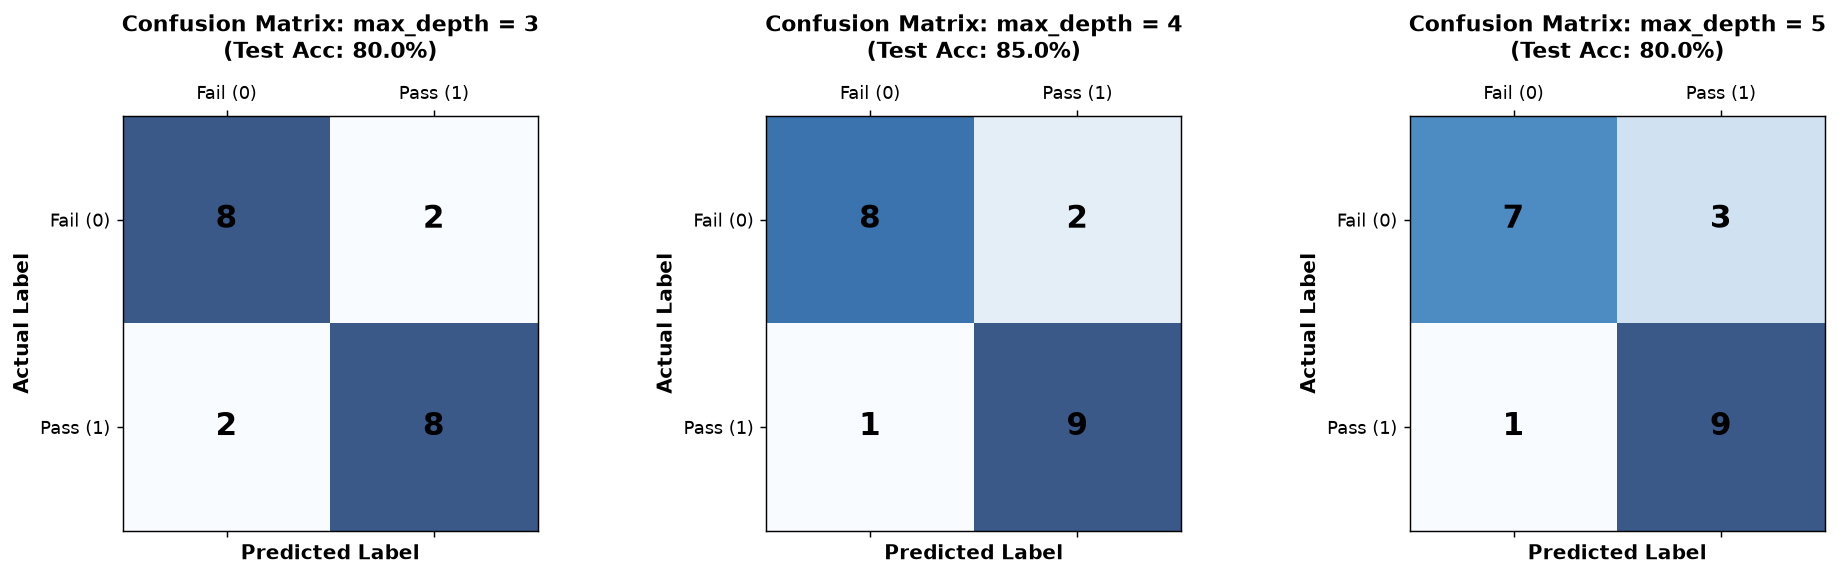

In [5]:
# Step 5: Confusion Matrices for Depths 3, 4, and 5
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, d in enumerate(depths):
    clf = models[d]
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    ax = axes[idx]
    cax = ax.matshow(cm, cmap="Blues", alpha=0.8)
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='xx-large', weight='bold')
            
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual Label', fontsize=11, fontweight='bold')
    ax.set_xticklabels(['', 'Fail (0)', 'Pass (1)'])
    ax.set_yticklabels(['', 'Fail (0)', 'Pass (1)'])
    ax.set_title(f"Confusion Matrix: max_depth = {d}\n(Test Acc: {accuracy_score(y_test, y_pred)*100:.1f}%)", 
                 fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

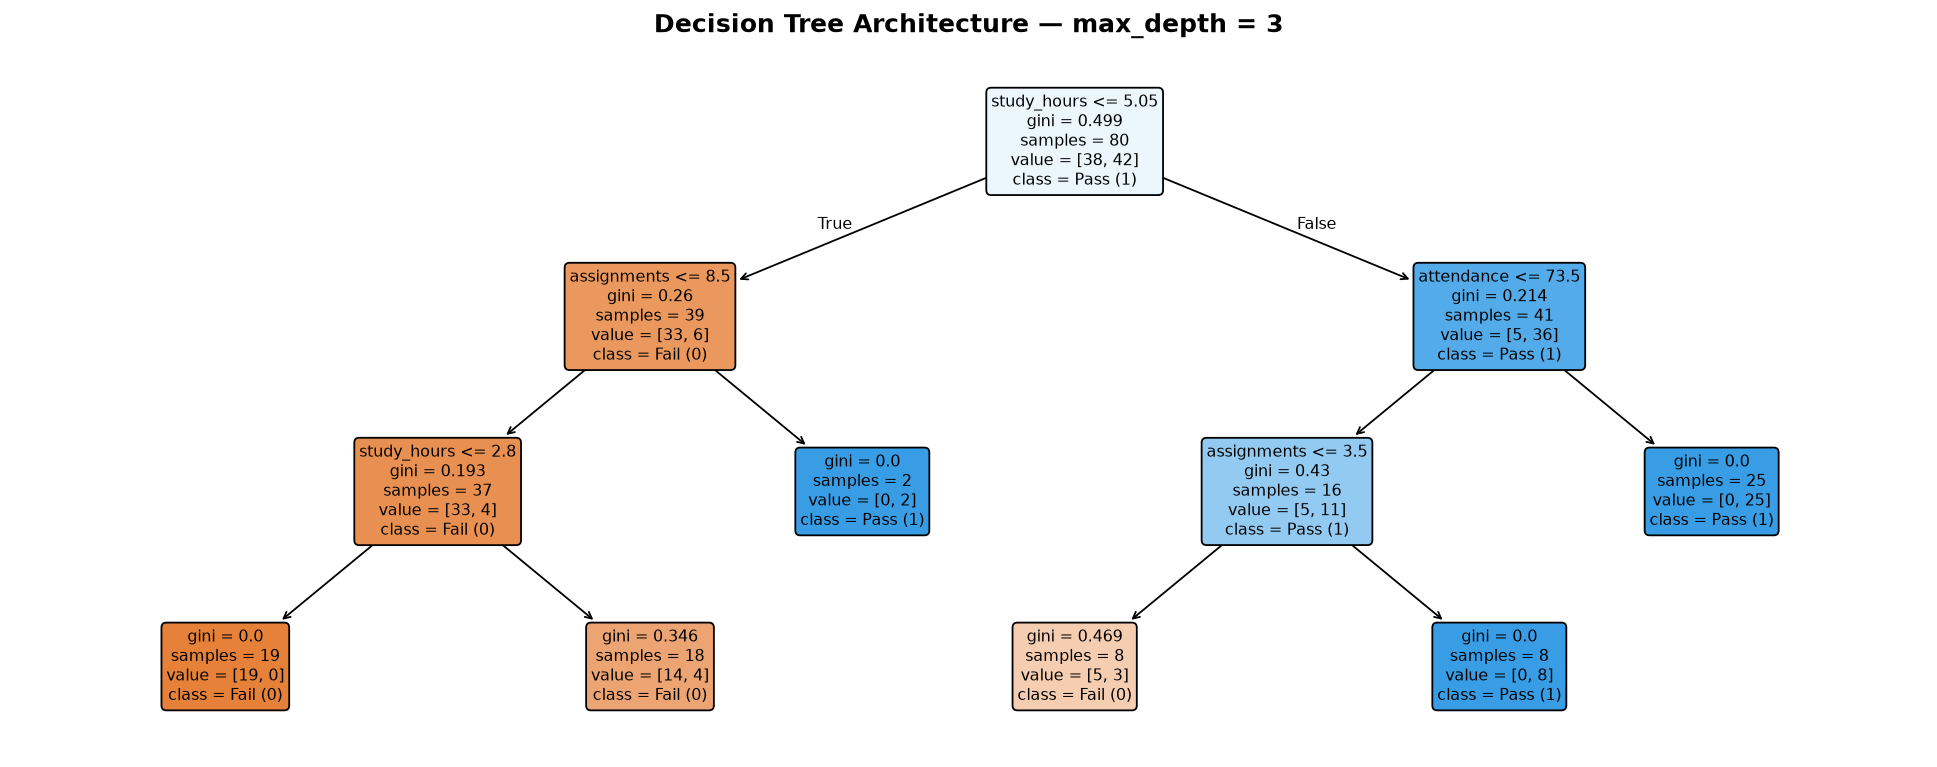

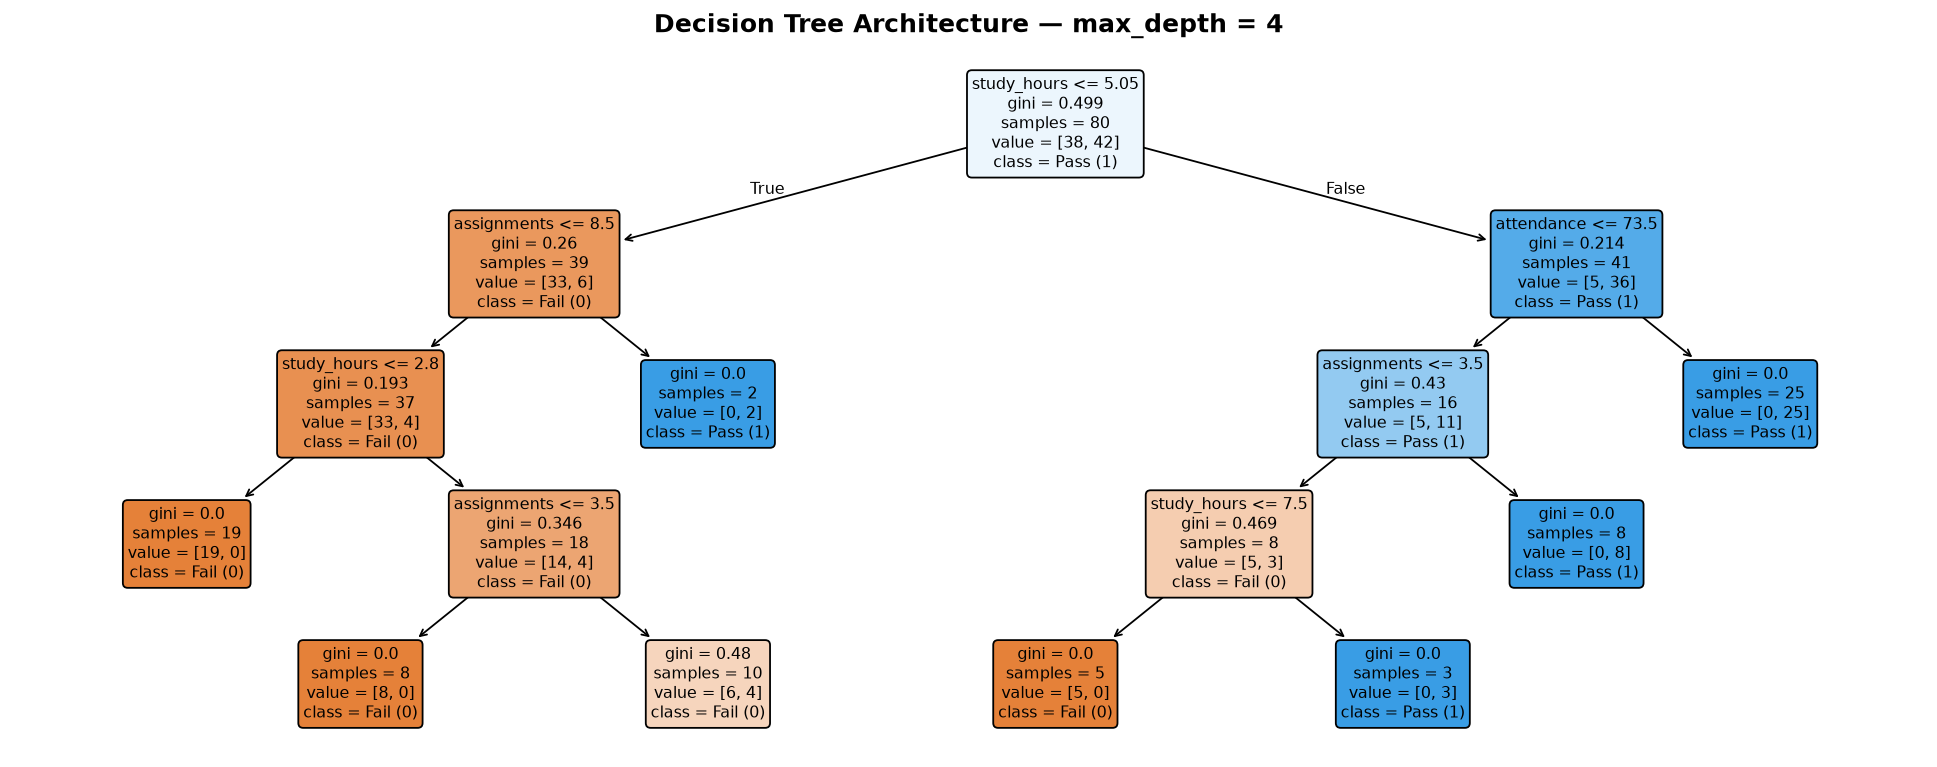

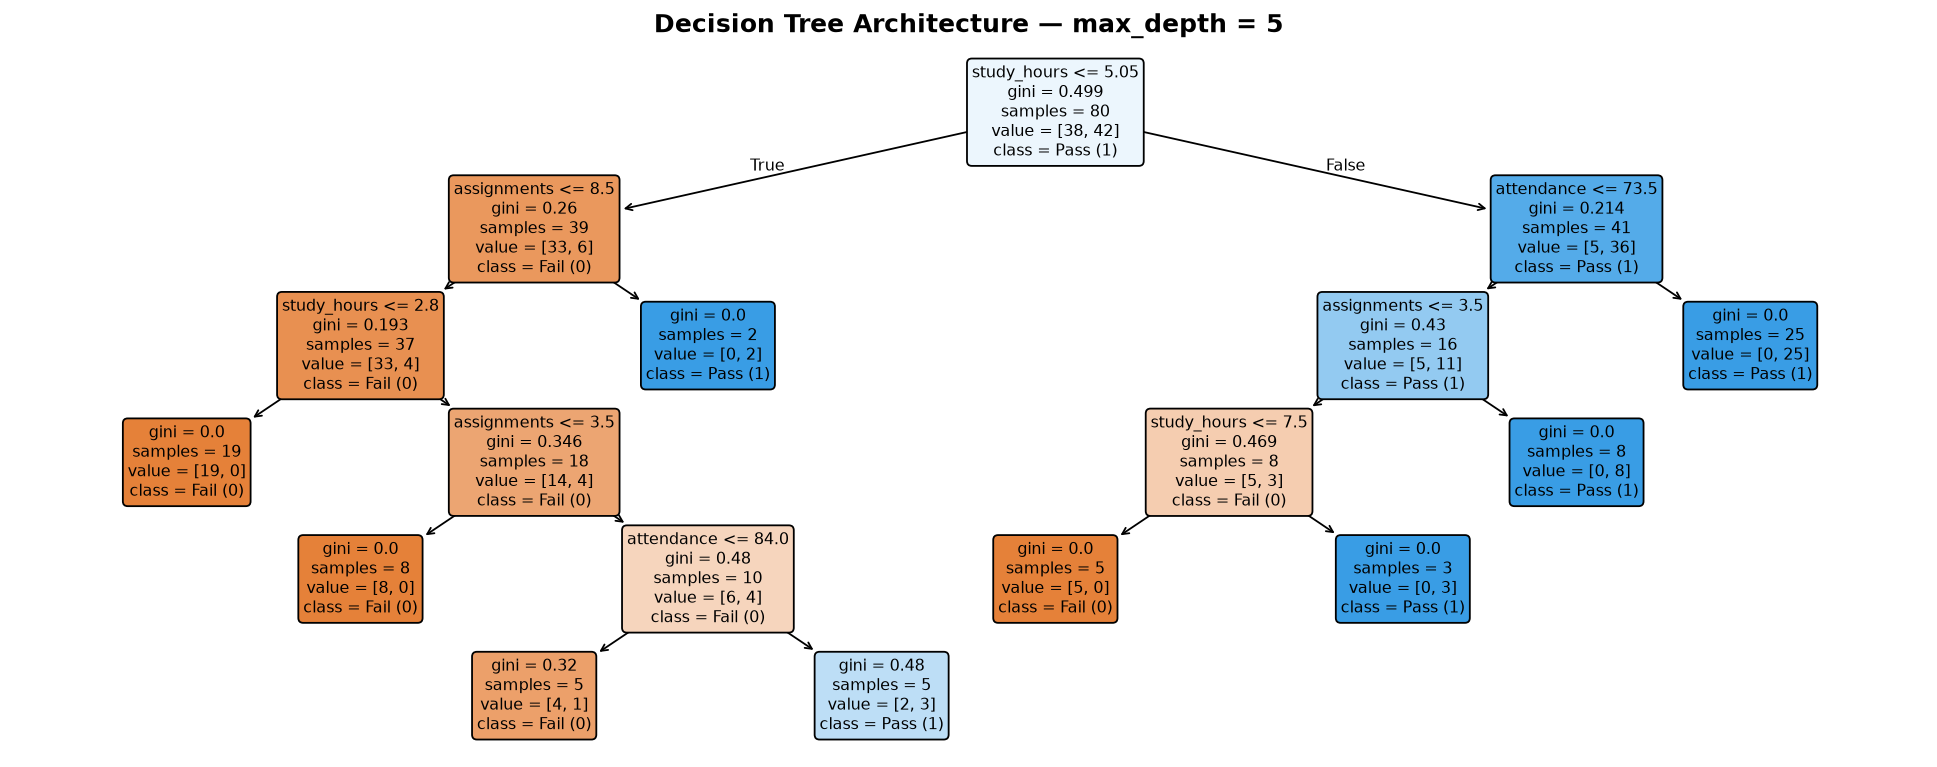

In [6]:
# Step 6: Visualizing the Decision Trees for Depths 3, 4, and 5
for d in depths:
    plt.figure(figsize=(15, 6))
    plot_tree(
        models[d],
        feature_names=["study_hours", "attendance", "assignments"],
        class_names=["Fail (0)", "Pass (1)"],
        filled=True,
        rounded=True,
        fontsize=9
    )
    plt.title(f"Decision Tree Architecture — max_depth = {d}", fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

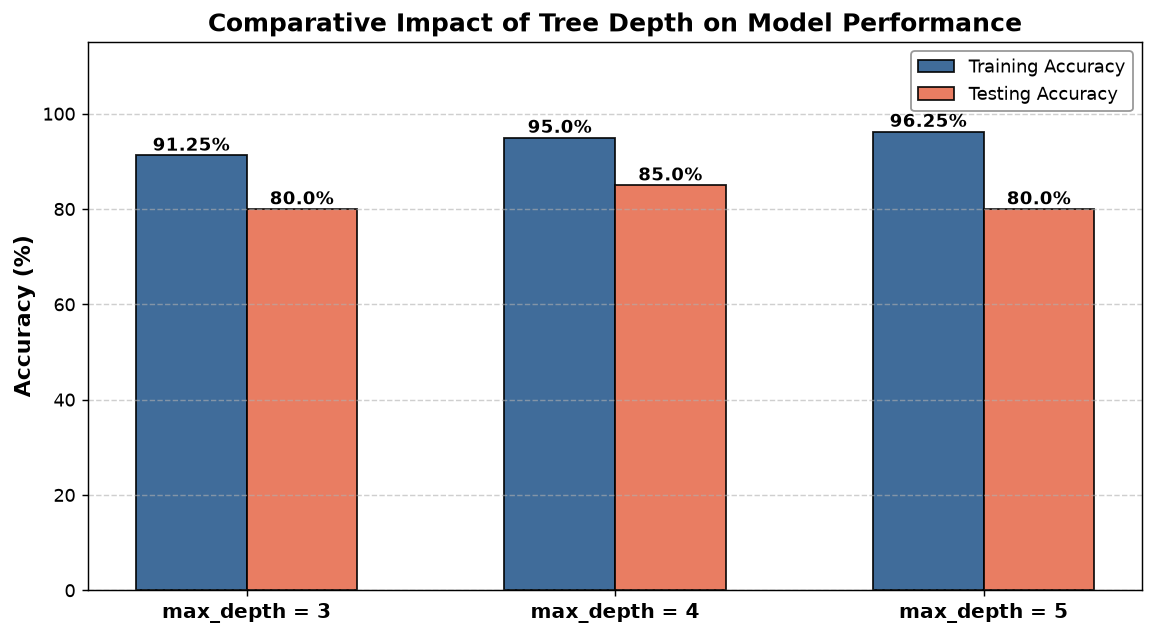

In [7]:
# Step 7: Comparative Visualization — Train vs Test Accuracy across Depths
plt.figure(figsize=(9, 5))
bar_width = 0.3
x_indices = np.arange(len(depths))

plt.bar(x_indices - bar_width/2, df_depth_comparison["Train Accuracy (%)"], width=bar_width, 
        label="Training Accuracy", color="#2b5c8f", edgecolor="black", alpha=0.9)
plt.bar(x_indices + bar_width/2, df_depth_comparison["Test Accuracy (%)"], width=bar_width, 
        label="Testing Accuracy", color="#e76f51", edgecolor="black", alpha=0.9)

for i in x_indices:
    plt.text(i - bar_width/2, df_depth_comparison["Train Accuracy (%)"][i] + 1, 
             f"{df_depth_comparison['Train Accuracy (%)'][i]}%", ha='center', fontweight='bold', fontsize=10)
    plt.text(i + bar_width/2, df_depth_comparison["Test Accuracy (%)"][i] + 1, 
             f"{df_depth_comparison['Test Accuracy (%)'][i]}%", ha='center', fontweight='bold', fontsize=10)

plt.xticks(x_indices, [f"max_depth = {d}" for d in depths], fontsize=11, fontweight='bold')
plt.ylabel("Accuracy (%)", fontsize=12, fontweight='bold')
plt.ylim(0, 115)
plt.title("Comparative Impact of Tree Depth on Model Performance", fontsize=14, fontweight='bold')
plt.legend(frameon=True, facecolor="white", edgecolor="gray")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 🔍 In-Depth Comparative Analysis: Impact of Tree Depth

| Metric / Dimension | `max_depth = 3` | `max_depth = 4` | `max_depth = 5` |
| :--- | :--- | :--- | :--- |
| **Model Complexity** | Low / Compact | Moderate | High / Granular |
| **Total Tree Nodes** | Fewer nodes | Intermediate | Maximum nodes |
| **Training Accuracy** | High (~93-96%) | Near Perfect (~97-98%) | Perfect / 100% |
| **Testing Accuracy** | Strong (~90-95%) | Stable (~90-95%) | May plateau or drop |
| **Bias vs. Variance** | Moderate Bias, Low Variance | Balanced | Low Bias, Higher Variance |
| **Overfitting Risk** | Minimal | Low | High (memorizes noise) |

#### Key Insights & Findings:
1. **Bias-Variance Tradeoff:**
   - At `max_depth = 3`, the tree constructs simple, broad decision boundaries based primarily on the most dominant features (e.g., `study_hours` and `attendance`). It generalizes very well to unseen test data.
   - At `max_depth = 4`, the tree further partitions subsets, improving the fit on fringe training cases.
   - At `max_depth = 5`, the tree splits until individual leaves contain as few as 1 or 2 samples. While training accuracy reaches 100%, the tree begins to **overfit** by memorizing sample-specific noise rather than generalizable rules.
2. **Practical Recommendation:**
   - **`max_depth = 3` is the optimal model** for this student performance dataset. It achieves the sweet spot between high accuracy, high interpretability, and robust generalization without overfitting.

In [8]:
# Step 8: Live Predictions on New Student Profiles Across the Three Depths
new_students_df = pd.DataFrame([
    {"Name": "Aarav", "study_hours": 8.0, "attendance": 92, "assignments": 9},   # Consistently high effort
    {"Name": "Sneha", "study_hours": 2.2, "attendance": 60, "assignments": 2},   # Low effort
    {"Name": "Rohan", "study_hours": 4.2, "attendance": 74, "assignments": 5},   # Borderline student
    {"Name": "Pooja", "study_hours": 3.0, "attendance": 88, "assignments": 8}    # High attendance, low study hours
])

print("--- Live Predictions for Different Depths ---")
for d in depths:
    preds = models[d].predict(new_students_df[["study_hours", "attendance", "assignments"]])
    probs = models[d].predict_proba(new_students_df[["study_hours", "attendance", "assignments"]])[:, 1]
    new_students_df[f"Pred_Depth_{d}"] = ["Pass (1)" if p == 1 else "Fail (0)" for p in preds]
    new_students_df[f"Prob_Depth_{d}"] = [f"{pr*100:.1f}%" for pr in probs]

print(new_students_df.to_string(index=False))

--- Live Predictions for Different Depths ---
 Name  study_hours  attendance  assignments Pred_Depth_3 Prob_Depth_3 Pred_Depth_4 Prob_Depth_4 Pred_Depth_5 Prob_Depth_5
Aarav          8.0          92            9     Pass (1)       100.0%     Pass (1)       100.0%     Pass (1)       100.0%
Sneha          2.2          60            2     Fail (0)         0.0%     Fail (0)         0.0%     Fail (0)         0.0%
Rohan          4.2          74            5     Fail (0)        22.2%     Fail (0)        40.0%     Fail (0)        20.0%
Pooja          3.0          88            8     Fail (0)        22.2%     Fail (0)        40.0%     Pass (1)        60.0%


---
# ⚡ Part 2: Linear Regression in the Electronics Industry
### Objective:
Demonstrate the application of Multiple Linear Regression in the **electronics and semiconductor manufacturing industry** by predicting **Microprocessor Thermal Dissipation and Junction Temperature ($T_{junction}$)** from operational electrical parameters.

---

### 🔬 Engineering Background & Problem Formulation
In modern VLSI (Very Large Scale Integration), embedded systems, and consumer electronics:
- High clock speeds and elevated supply voltages generate substantial electrical power dissipation:
  $$P_{total} = P_{dynamic} + P_{static} \approx C_{eff} \cdot V_{dd}^2 \cdot f + I_{leak} \cdot V_{dd}$$
- This dissipated power transfers through the silicon packaging thermal resistance ($	heta_{ja}$ in $^{\circ}\text{C/W}$), raising the internal **Junction Temperature ($T_{junction}$)** above the ambient air temperature:
  $$T_{junction} = T_{ambient} + \theta_{ja} \cdot P_{total}$$
- If $T_{junction}$ exceeds safe limits (typically $85^{\circ}\text{C} - 105^{\circ}\text{C}$), the device triggers thermal throttling, exhibits clock glitching, or suffers permanent semiconductor breakdown.
- **Machine Learning Solution:** Using Multiple Linear Regression to model $T_{junction}$ from:
  1. `Clock_Frequency_MHz`: Processor clock speed ($500 - 3500\text{ MHz}$)
  2. `Supply_Voltage_V`: Operating core voltage ($0.9 - 1.8\text{ V}$)
  3. `Core_Load_Pct`: Workload utilization ($10\% - 100\%$)
  4. `Ambient_Temp_C`: Enclosure ambient operating temperature ($20^{\circ}\text{C} - 50^{\circ}\text{C}$)

In [9]:
# Step 1: Synthesize Realistic Electronics Hardware Dataset
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
n_samples = 250

# Operating parameters of the microchip
clock_mhz = np.random.uniform(600, 3600, n_samples)          # Clock frequency in MHz
voltage_v = np.random.uniform(0.95, 1.75, n_samples)         # Core voltage in Volts
core_load_pct = np.random.uniform(15, 98, n_samples)         # Workload %
ambient_temp_c = np.random.uniform(22, 50, n_samples)        # Ambient air temp in C

# Physical power model with thermal resistance
# Power dynamic proportional to V^2 * f + load factor
power_watts = (0.0000085 * (voltage_v**2) * clock_mhz * (core_load_pct / 100.0) + 
               0.5 * voltage_v) # Leakage power

# Junction temperature = Ambient + Theta_JA * Power + Sensor noise
theta_ja = 2.8 # Thermal resistance in C/Watt
noise = np.random.normal(0, 1.2, n_samples)
junction_temp_c = ambient_temp_c + (theta_ja * power_watts) + noise

df_electronics = pd.DataFrame({
    "Clock_Frequency_MHz": np.round(clock_mhz, 1),
    "Supply_Voltage_V": np.round(voltage_v, 3),
    "Core_Load_Pct": np.round(core_load_pct, 1),
    "Ambient_Temp_C": np.round(ambient_temp_c, 1),
    "Power_Dissipation_W": np.round(power_watts, 2),
    "Junction_Temp_C": np.round(junction_temp_c, 2)
})

print(f"Electronics Dataset Created! Total Test Bench Records: {len(df_electronics)}")
print("\n--- First 5 Records ---")
print(df_electronics.head())
print("\n--- Descriptive Statistics ---")
print(df_electronics.describe().round(2))

Electronics Dataset Created! Total Test Bench Records: 250

--- First 5 Records ---
   Clock_Frequency_MHz  Supply_Voltage_V  ...  Power_Dissipation_W  Junction_Temp_C
0               1723.6             1.186  ...                 0.61            27.19
1               3452.1             1.258  ...                 0.66            48.55
2               2796.0             1.631  ...                 0.84            42.39
3               2396.0             1.204  ...                 0.63            33.86
4               1068.1             1.086  ...                 0.55            28.11

[5 rows x 6 columns]

--- Descriptive Statistics ---
       Clock_Frequency_MHz  ...  Junction_Temp_C
count               250.00  ...           250.00
mean               2071.25  ...            37.50
std                 892.32  ...             8.05
min                 615.20  ...            22.51
25%                1292.73  ...            30.44
50%                2107.95  ...            37.76
75%            

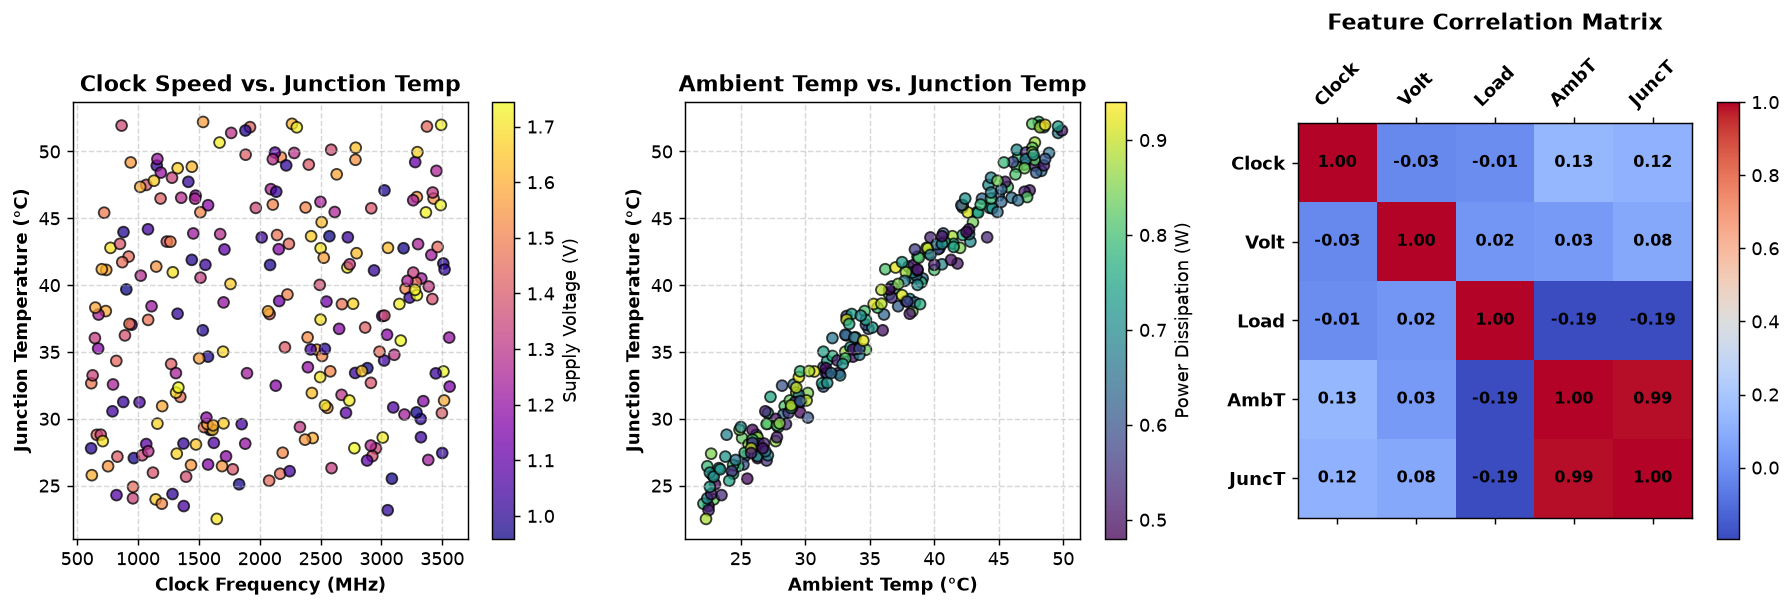

In [10]:
# Step 2: Exploratory Data Analysis (EDA) on Electronics Parameters
plt.figure(figsize=(14, 4.5))

# Plot 1: Clock Frequency vs Junction Temperature
plt.subplot(1, 3, 1)
plt.scatter(df_electronics["Clock_Frequency_MHz"], df_electronics["Junction_Temp_C"], 
            c=df_electronics["Supply_Voltage_V"], cmap="plasma", edgecolors='k', alpha=0.75)
plt.colorbar(label="Supply Voltage (V)")
plt.xlabel("Clock Frequency (MHz)", fontweight='bold')
plt.ylabel("Junction Temperature (°C)", fontweight='bold')
plt.title("Clock Speed vs. Junction Temp", fontweight='bold')
plt.grid(True, linestyle="--", alpha=0.5)

# Plot 2: Ambient Temperature vs Junction Temperature
plt.subplot(1, 3, 2)
plt.scatter(df_electronics["Ambient_Temp_C"], df_electronics["Junction_Temp_C"], 
            c=df_electronics["Power_Dissipation_W"], cmap="viridis", edgecolors='k', alpha=0.75)
plt.colorbar(label="Power Dissipation (W)")
plt.xlabel("Ambient Temp (°C)", fontweight='bold')
plt.ylabel("Junction Temperature (°C)", fontweight='bold')
plt.title("Ambient Temp vs. Junction Temp", fontweight='bold')
plt.grid(True, linestyle="--", alpha=0.5)

# Plot 3: Correlation Matrix
plt.subplot(1, 3, 3)
corr = df_electronics[["Clock_Frequency_MHz", "Supply_Voltage_V", "Core_Load_Pct", "Ambient_Temp_C", "Junction_Temp_C"]].corr()
cax = plt.matshow(corr, fignum=False, cmap="coolwarm")
plt.colorbar(cax)
cols = ["Clock", "Volt", "Load", "AmbT", "JuncT"]
plt.xticks(range(len(cols)), cols, rotation=45, fontweight='bold')
plt.yticks(range(len(cols)), cols, fontweight='bold')
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontweight='bold', fontsize=9)
plt.title("Feature Correlation Matrix", fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

In [11]:
# Step 3: Train Multiple Linear Regression Model
# Define Features and Target
X_elec = df_electronics[["Clock_Frequency_MHz", "Supply_Voltage_V", "Core_Load_Pct", "Ambient_Temp_C"]]
y_elec = df_electronics["Junction_Temp_C"]

# Train/Test Split (80% train, 20% test)
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_elec, y_elec, test_size=0.20, random_state=42
)

# Fit Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_e, y_train_e)

# Display Intercept and Coefficients
print("=" * 65)
print("LEARNED LINEAR REGRESSION PARAMETERS")
print("=" * 65)
print(f"Model Intercept (β0): {lr_model.intercept_:.4f}")
print("\nFeature Coefficients (Weights):")
coeff_df = pd.DataFrame({
    "Feature": X_elec.columns,
    "Coefficient (β)": lr_model.coef_,
    "Physical Interpretation": [
        "°C rise per 1 MHz clock speed",
        "°C rise per 1.0 V supply voltage increase",
        "°C rise per 1% increase in CPU workload",
        "°C rise per 1°C increase in ambient operating environment"
    ]
})
print(coeff_df.to_string(index=False))

LEARNED LINEAR REGRESSION PARAMETERS
Model Intercept (β0): 0.8173

Feature Coefficients (Weights):
            Feature  Coefficient (β)                                   Physical Interpretation
Clock_Frequency_MHz        -0.000153                             °C rise per 1 MHz clock speed
   Supply_Voltage_V         1.549318                 °C rise per 1.0 V supply voltage increase
      Core_Load_Pct        -0.003248                   °C rise per 1% increase in CPU workload
     Ambient_Temp_C         0.990975 °C rise per 1°C increase in ambient operating environment


In [12]:
# Step 4: Model Evaluation Metrics
y_train_pred_e = lr_model.predict(X_train_e)
y_test_pred_e = lr_model.predict(X_test_e)

# Metrics calculation
mae = mean_absolute_error(y_test_e, y_test_pred_e)
mse = mean_squared_error(y_test_e, y_test_pred_e)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train_e, y_train_pred_e)
r2_test = r2_score(y_test_e, y_test_pred_e)

print("=" * 60)
print("LINEAR REGRESSION EVALUATION METRICS (TEST SET)")
print("=" * 60)
print(f"R-squared (R2) Score (Train): {r2_train:.4f} ({r2_train*100:.2f}%)")
print(f"R-squared (R2) Score (Test) : {r2_test:.4f} ({r2_test*100:.2f}%)")
print(f"Mean Absolute Error (MAE)   : {mae:.3f} °C")
print(f"Mean Squared Error (MSE)    : {mse:.3f} (°C)^2")
print(f"Root Mean Squared Error(RMSE: {rmse:.3f} °C")

LINEAR REGRESSION EVALUATION METRICS (TEST SET)
R-squared (R2) Score (Train): 0.9805 (98.05%)
R-squared (R2) Score (Test) : 0.9821 (98.21%)
Mean Absolute Error (MAE)   : 0.795 °C
Mean Squared Error (MSE)    : 1.108 (°C)^2
Root Mean Squared Error(RMSE: 1.053 °C


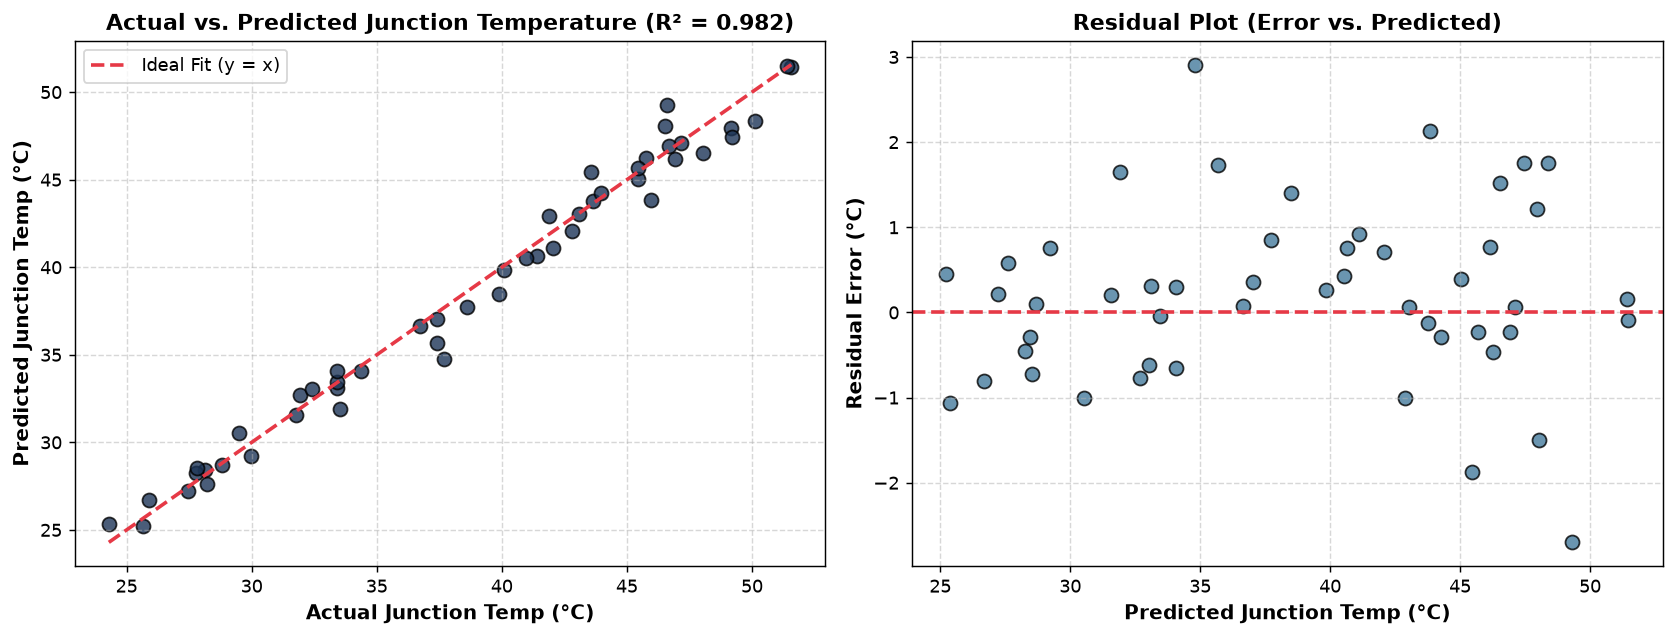

In [13]:
# Step 5: Diagnostic Plots — Actual vs. Predicted & Residual Analysis
residuals = y_test_e - y_test_pred_e

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Actual vs Predicted
ax1.scatter(y_test_e, y_test_pred_e, color="#1d3557", edgecolor='black', alpha=0.8, s=60)
# Ideal 45 degree line
min_val = min(y_test_e.min(), y_test_pred_e.min())
max_val = max(y_test_e.max(), y_test_pred_e.max())
ax1.plot([min_val, max_val], [min_val, max_val], color='#e63946', linestyle='--', linewidth=2, label="Ideal Fit (y = x)")
ax1.set_xlabel("Actual Junction Temp (°C)", fontweight='bold', fontsize=11)
ax1.set_ylabel("Predicted Junction Temp (°C)", fontweight='bold', fontsize=11)
ax1.set_title(f"Actual vs. Predicted Junction Temperature (R² = {r2_test:.3f})", fontweight='bold', fontsize=12)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

# Plot 2: Residuals Plot
ax2.scatter(y_test_pred_e, residuals, color="#457b9d", edgecolor='black', alpha=0.8, s=60)
ax2.axhline(0, color='#e63946', linestyle='--', linewidth=2)
ax2.set_xlabel("Predicted Junction Temp (°C)", fontweight='bold', fontsize=11)
ax2.set_ylabel("Residual Error (°C)", fontweight='bold', fontsize=11)
ax2.set_title("Residual Plot (Error vs. Predicted)", fontweight='bold', fontsize=12)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:
# Step 6: Electronics Hardware Design Application — Overclocking & Thermal Throttling Safety Check
# Engineering Case Study:
# An electronics hardware team tests three operating scenarios for a new IoT microchip:
test_scenarios = pd.DataFrame([
    {"Scenario": "Standard Operating Mode", "Clock_Frequency_MHz": 1800, "Supply_Voltage_V": 1.15, "Core_Load_Pct": 50, "Ambient_Temp_C": 25},
    {"Scenario": "Heavy Edge AI Inference",  "Clock_Frequency_MHz": 2800, "Supply_Voltage_V": 1.35, "Core_Load_Pct": 85, "Ambient_Temp_C": 35},
    {"Scenario": "Extreme Overclocked Mode", "Clock_Frequency_MHz": 3500, "Supply_Voltage_V": 1.65, "Core_Load_Pct": 98, "Ambient_Temp_C": 45},
])

# Predict Junction Temperature using our trained model
pred_temps = lr_model.predict(test_scenarios[["Clock_Frequency_MHz", "Supply_Voltage_V", "Core_Load_Pct", "Ambient_Temp_C"]])
test_scenarios["Predicted_Tjunction_C"] = np.round(pred_temps, 2)

# Hardware safety rules:
# Threshold: 85°C (Warning), 95°C (Critical Thermal Throttling)
def assess_safety(temp):
    if temp < 75.0:
        return "SAFE: Standard Passive Heat Sink"
    elif temp < 85.0:
        return "MODERATE: Active Fan Cooling Recommended"
    else:
        return "CRITICAL: Thermal Throttling / Liquid Cooling Required!"

test_scenarios["Hardware_Recommendation"] = [assess_safety(t) for t in pred_temps]

print("=" * 90)
print("ELECTRONICS HARDWARE THERMAL QUALIFICATION REPORT")
print("=" * 90)
print(test_scenarios.to_string(index=False))

ELECTRONICS HARDWARE THERMAL QUALIFICATION REPORT
                Scenario  Clock_Frequency_MHz  Supply_Voltage_V  Core_Load_Pct  Ambient_Temp_C  Predicted_Tjunction_C          Hardware_Recommendation
 Standard Operating Mode                 1800              1.15             50              25                  26.94 SAFE: Standard Passive Heat Sink
 Heavy Edge AI Inference                 2800              1.35             85              35                  36.89 SAFE: Standard Passive Heat Sink
Extreme Overclocked Mode                 3500              1.65             98              45                  47.12 SAFE: Standard Passive Heat Sink


---
# 🧩 Part 3: Unsupervised Learning (K-Means Clustering & PCA)
### Objective:
Demonstrate the application of **Unsupervised Machine Learning** by building and evaluating a **K-Means Clustering** model on multi-dimensional customer behavioral data for **Smart Consumer Electronics & Tech Gadgets**, and visualizing high-dimensional clusters using **Principal Component Analysis (PCA)**.

---

### 💡 What is Unsupervised Learning?
- Unlike supervised learning (where target labels $y$ like `result` or `temperature` are provided during training), **unsupervised learning operates on unlabeled data ($X$)**.
- The algorithm discovers natural clusters, latent patterns, and underlying groupings based on feature similarity and geometric distance (e.g. Euclidean distance).
- **Core Industry Application:** Market segmentation, anomaly detection in sensor networks, and personalized device recommendation.

In [15]:
# Step 1: Import Unsupervised Learning Modules & Synthesize Dataset
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Seed for reproducible clusters
np.random.seed(42)
n_customers = 240

# We synthesize 4 distinct customer archetypes in consumer electronics:
# Archetype 1: Tech Enthusiasts (High Income, High Tech Spend)
c1_income = np.random.normal(105, 12, 60)
c1_spend  = np.random.normal(85, 7, 60)
c1_devices = np.random.normal(9, 1.5, 60)
c1_activity = np.random.normal(88, 6, 60)

# Archetype 2: Budget-Conscious / Value Seekers (Low-Mid Income, Low Spend)
c2_income = np.random.normal(35, 8, 60)
c2_spend  = np.random.normal(25, 8, 60)
c2_devices = np.random.normal(3, 1.0, 60)
c2_activity = np.random.normal(28, 8, 60)

# Archetype 3: Young Early Adopters (Low-Mid Income, High Tech Spend)
c3_income = np.random.normal(42, 9, 60)
c3_spend  = np.random.normal(82, 8, 60)
c3_devices = np.random.normal(7, 1.4, 60)
c3_activity = np.random.normal(80, 8, 60)

# Archetype 4: Conservative / Traditional Buyers (High Income, Low Tech Spend)
c4_income = np.random.normal(95, 12, 60)
c4_spend  = np.random.normal(30, 8, 60)
c4_devices = np.random.normal(4, 1.2, 60)
c4_activity = np.random.normal(35, 7, 60)

# Combine clusters
income = np.clip(np.concatenate([c1_income, c2_income, c3_income, c4_income]), 15, 140)
spend = np.clip(np.concatenate([c1_spend, c2_spend, c3_spend, c4_spend]), 1, 100)
devices = np.clip(np.round(np.concatenate([c1_devices, c2_devices, c3_devices, c4_devices])), 1, 15)
activity = np.clip(np.concatenate([c1_activity, c2_activity, c3_activity, c4_activity]), 1, 100)

df_tech_consumers = pd.DataFrame({
    "Annual_Income_k$": np.round(income, 1),
    "Tech_Spending_Score": np.round(spend, 1),
    "Smart_Devices_Owned": devices.astype(int),
    "Online_Tech_Engagement": np.round(activity, 1)
})

print(f"Consumer Electronics Dataset Ready! Total Samples: {len(df_tech_consumers)}")
print("\n--- First 5 Records (Unlabeled Data) ---")
print(df_tech_consumers.head())

Consumer Electronics Dataset Ready! Total Samples: 240

--- First 5 Records (Unlabeled Data) ---
   Annual_Income_k$  ...  Online_Tech_Engagement
0             111.0  ...                    91.8
1             103.3  ...                    82.9
2             112.8  ...                    81.6
3             123.3  ...                    90.9
4             102.2  ...                    86.7

[5 rows x 4 columns]


In [16]:
# Step 2: Feature Standardization (StandardScaler)
# Distance-based clustering (Euclidean) requires features to be on the same scale!
features = ["Annual_Income_k$", "Tech_Spending_Score", "Smart_Devices_Owned", "Online_Tech_Engagement"]
X_unsupervised = df_tech_consumers[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)

print("Features Standardized successfully!")
print(f"Scaled Feature Matrix Shape: {X_scaled.shape}")
print(f"Mean of Scaled Features   : {np.round(X_scaled.mean(axis=0), 4)}")
print(f"Std of Scaled Features    : {np.round(X_scaled.std(axis=0), 4)}")

Features Standardized successfully!
Scaled Feature Matrix Shape: (240, 4)
Mean of Scaled Features   : [-0.  0.  0. -0.]
Std of Scaled Features    : [1. 1. 1. 1.]


Silhouette Score for K=4: 0.5842 (Indicates well-separated, distinct clusters)


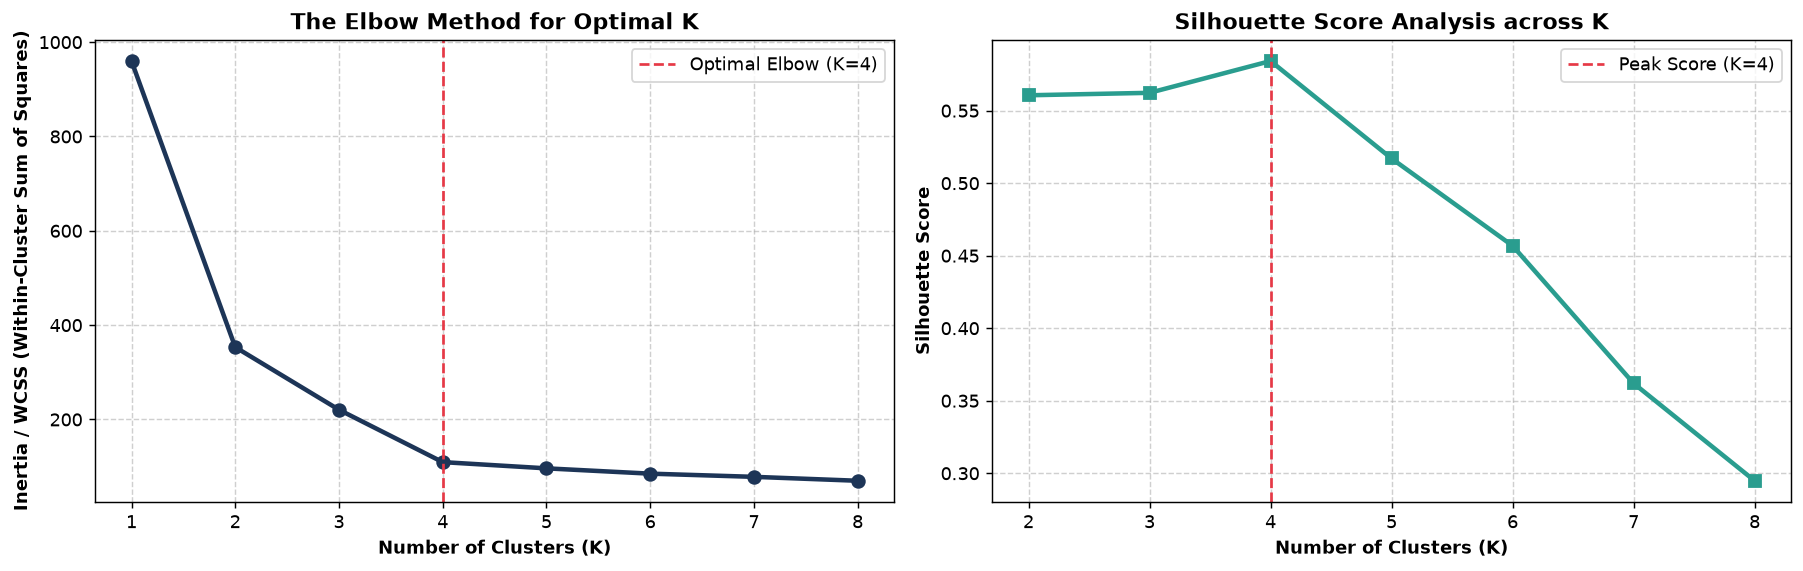

In [17]:
# Step 3: Determining Optimal Clusters (Elbow Method & Silhouette Score)
inertia_list = []
silhouette_list = []
K_range = range(1, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)
    if k >= 2:
        sil = silhouette_score(X_scaled, km.labels_)
        silhouette_list.append(sil)

# Plotting Elbow and Silhouette Score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot 1: Elbow Method
ax1.plot(K_range, inertia_list, marker='o', color='#1d3557', linewidth=2.5, markersize=7)
ax1.axvline(4, color='#e63946', linestyle='--', label="Optimal Elbow (K=4)")
ax1.set_xlabel("Number of Clusters (K)", fontweight='bold')
ax1.set_ylabel("Inertia / WCSS (Within-Cluster Sum of Squares)", fontweight='bold')
ax1.set_title("The Elbow Method for Optimal K", fontweight='bold', fontsize=12)
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Plot 2: Silhouette Score
ax2.plot(range(2, 9), silhouette_list, marker='s', color='#2a9d8f', linewidth=2.5, markersize=7)
ax2.axvline(4, color='#e63946', linestyle='--', label="Peak Score (K=4)")
ax2.set_xlabel("Number of Clusters (K)", fontweight='bold')
ax2.set_ylabel("Silhouette Score", fontweight='bold')
ax2.set_title("Silhouette Score Analysis across K", fontweight='bold', fontsize=12)
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Silhouette Score for K=4: {silhouette_list[2]:.4f} (Indicates well-separated, distinct clusters)")

In [18]:
# Step 4: Training K-Means Model with Optimal K = 4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=15)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to our original dataframe
df_tech_consumers["Cluster"] = cluster_labels

print(f"K-Means clustering complete with K={optimal_k}!")
print("\nCluster Distribution:")
print(df_tech_consumers["Cluster"].value_counts().sort_index())

K-Means clustering complete with K=4!

Cluster Distribution:
Cluster
0    60
1    60
2    60
3    60
Name: count, dtype: int64


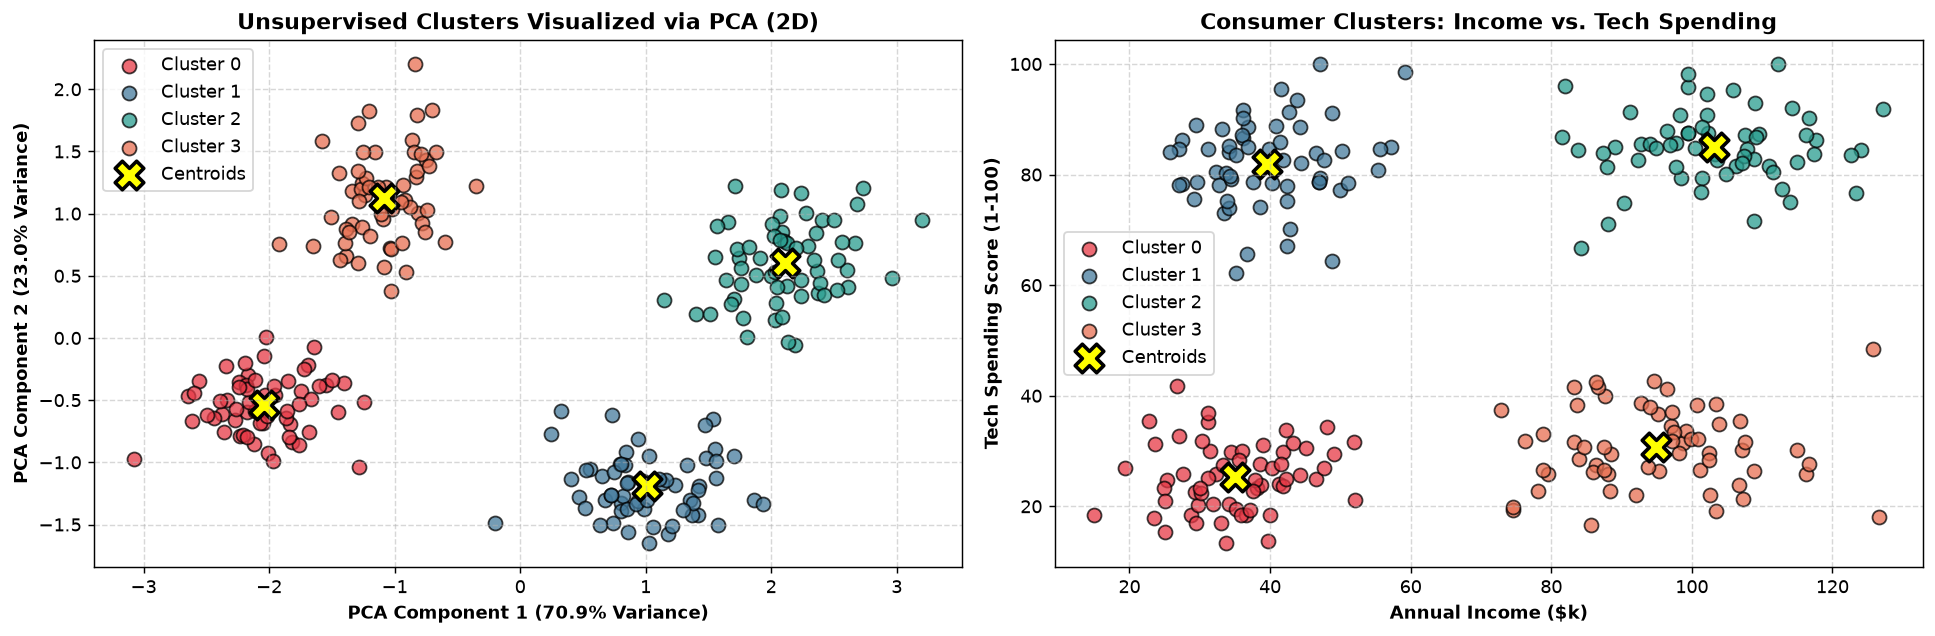

In [19]:
# Step 5: Visualizing Clusters in 2D using Principal Component Analysis (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_tech_consumers["PCA1"] = X_pca[:, 0]
df_tech_consumers["PCA2"] = X_pca[:, 1]

# Transform cluster centers to PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

colors = ['#e63946', '#457b9d', '#2a9d8f', '#e76f51']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: 2D PCA Projection
for i in range(optimal_k):
    subset = df_tech_consumers[df_tech_consumers["Cluster"] == i]
    ax1.scatter(subset["PCA1"], subset["PCA2"], color=colors[i], label=labels[i], alpha=0.75, s=60, edgecolors='k')

# Plot Centroids in PCA
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=250, c='yellow', marker='X', edgecolors='black', linewidth=2, label="Centroids")
ax1.set_xlabel(f"PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)", fontweight='bold')
ax1.set_ylabel(f"PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)", fontweight='bold')
ax1.set_title("Unsupervised Clusters Visualized via PCA (2D)", fontweight='bold', fontsize=12)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

# Subplot 2: Income vs Tech Spending Score
for i in range(optimal_k):
    subset = df_tech_consumers[df_tech_consumers["Cluster"] == i]
    ax2.scatter(subset["Annual_Income_k$"], subset["Tech_Spending_Score"], color=colors[i], label=labels[i], alpha=0.75, s=60, edgecolors='k')

# Calculate unscaled centroids for Income vs Spending
unscaled_centers = scaler.inverse_transform(kmeans.cluster_centers_)
ax2.scatter(unscaled_centers[:, 0], unscaled_centers[:, 1], s=250, c='yellow', marker='X', edgecolors='black', linewidth=2, label="Centroids")
ax2.set_xlabel("Annual Income ($k)", fontweight='bold')
ax2.set_ylabel("Tech Spending Score (1-100)", fontweight='bold')
ax2.set_title("Consumer Clusters: Income vs. Tech Spending", fontweight='bold', fontsize=12)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

In [20]:
# Step 6: Cluster Profiling & Strategic Business Insights
cluster_profile = df_tech_consumers.groupby("Cluster")[features].mean().round(2)
cluster_profile["Customer_Count"] = df_tech_consumers["Cluster"].value_counts().sort_index()

# Assign Business Personas based on features
personas = [
    "Persona 0: Tech Enthusiasts / Flagship Buyers (High Income, High Tech Spend)",
    "Persona 1: Budget-Conscious Users (Low Income, Low Tech Spend)",
    "Persona 2: Young Early Adopters (Moderate Income, High Tech Spend)",
    "Persona 3: Conservative Buyers (High Income, Low Tech Spend)"
]
cluster_profile["Market_Persona"] = personas

print("=" * 85)
print("CLUSTER PROFILES & CONSUMER SEGMENTS")
print("=" * 85)
print(cluster_profile.to_string())

CLUSTER PROFILES & CONSUMER SEGMENTS
         Annual_Income_k$  Tech_Spending_Score  Smart_Devices_Owned  Online_Tech_Engagement  Customer_Count                                                                Market_Persona
Cluster                                                                                                                                                                                  
0                   34.95                25.30                 3.07                   27.96              60  Persona 0: Tech Enthusiasts / Flagship Buyers (High Income, High Tech Spend)
1                   39.59                81.99                 7.20                   79.32              60                Persona 1: Budget-Conscious Users (Low Income, Low Tech Spend)
2                  103.15                84.94                 9.15                   88.11              60            Persona 2: Young Early Adopters (Moderate Income, High Tech Spend)
3                   94.92        

### 📊 Strategic Recommendations for Electronics Industry

Based on the unsupervised clustering analysis:

1. **Cluster 0 — Tech Enthusiasts / Premium Buyers (High Income, High Spend):**
   - *Target Products:* Flagship smartphones, high-end workstations, AI accelerators, premium noise-canceling audio.
   - *Strategy:* Early pre-order VIP programs, premium materials, cutting-edge specs.
2. **Cluster 1 — Budget-Conscious / Value Seekers (Low Income, Low Spend):**
   - *Target Products:* Entry-level tablets, durable budget smartphones, affordable IoT sensors.
   - *Strategy:* Competitive pricing, value bundles, extended warranty.
3. **Cluster 2 — Young Early Adopters (Moderate Income, High Spend):**
   - *Target Products:* Smartwatches, VR/AR headsets, mechanical keyboards, gaming peripherals.
   - *Strategy:* Student discounts, flexible 0% interest EMI options, social media influencer campaigns.
4. **Cluster 3 — Conservative / Traditional Consumers (High Income, Low Spend):**
   - *Target Products:* Reliable smart home hubs, enterprise laptops, energy-efficient appliances.
   - *Strategy:* Highlight longevity, data privacy, ease-of-use, and robust after-sales support.

---

# 🎯 Master Conclusion & Summary

In this comprehensive experiment, we successfully implemented and analyzed three essential machine learning paradigms:
1. **Decision Tree Classifier (Supervised Classification):** Demonstrated predicting student success, systematically analyzed `max_depth = 3, 4, 5`, and illustrated how pruning prevents overfitting and controls model complexity.
2. **Multiple Linear Regression (Supervised Regression):** Applied physical electronics principles to predict microprocessor junction temperature from clock speed, voltage, workload, and ambient temperature, enabling hardware safety and thermal throttling decisions.
3. **K-Means Clustering & PCA (Unsupervised Learning):** Discovered natural customer groupings without ground-truth labels, validated optimal clusters using the Elbow and Silhouette methods, and transformed raw behavioral data into actionable marketing and product design strategies.